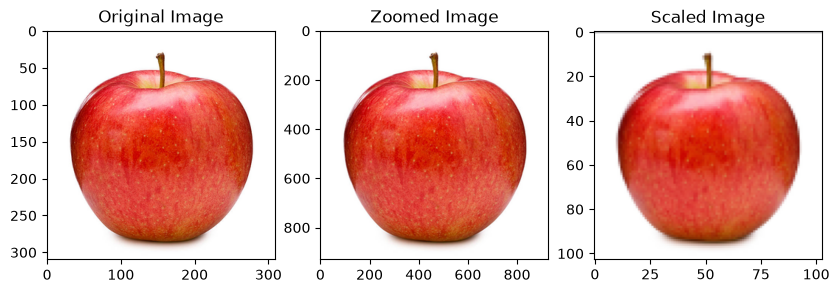

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("..\\apple.png")
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
height,width = image.shape[:2]
new_height = int(height*3.0)
new_weight = int(width*3.0)

zoomed_img = cv2.resize(
    image,
    (new_weight, new_height),
    interpolation=cv2.INTER_CUBIC
)

scaled_img = cv2.resize(
    image,
    (int(width/3.0),int(height/3.0)),
    interpolation=cv2.INTER_AREA
)

fig,axes = plt.subplots(1,3,figsize=(10,10))
axes[0].imshow(image)
axes[0].set_title("Original Image")

axes[1].imshow(zoomed_img)
axes[1].set_title("Zoomed Image")

axes[2].imshow(scaled_img)
axes[2].set_title("Scaled Image")

plt.show()

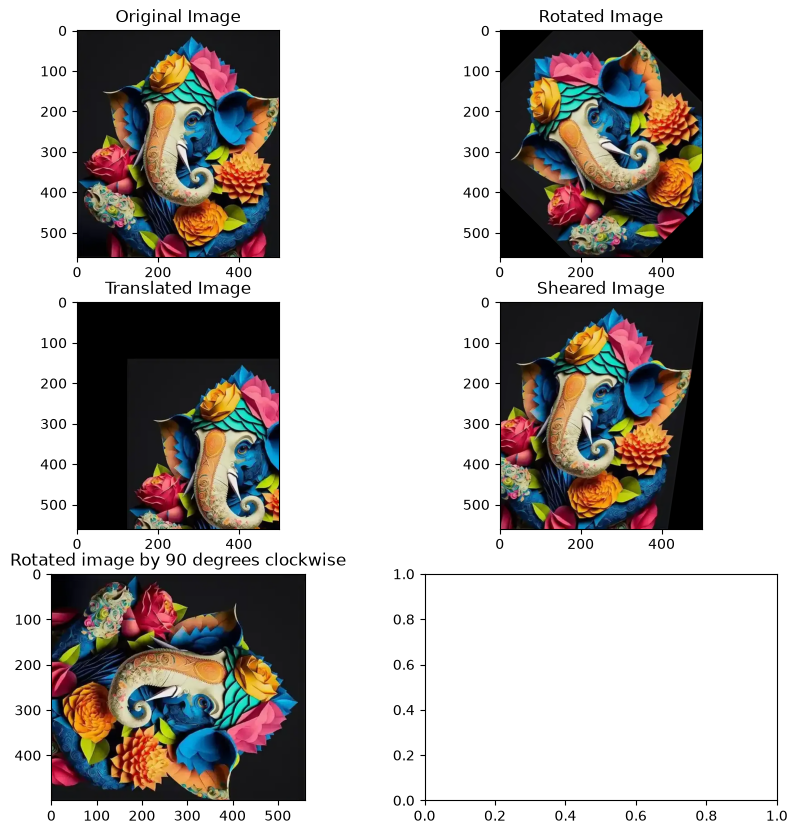

In [30]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("..\\fol\\Ganeshji.webp")
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)



# using rotation on the image
rotated_image = cv2.rotate(
    image,
    cv2.ROTATE_90_CLOCKWISE,
    (0, 0)
)


# ROTATED BY PARTICULAR ANGLE 
ang_rotated = cv2.getRotationMatrix2D(
    (image.shape[1]/2,image.shape[0]/2),
    45,
    1.0
)
ang_rotated_img = cv2.warpAffine(
    image,
    ang_rotated,
    (image.shape[1],image.shape[0])
)

# translated image
translation = np.array([[1,0,image.shape[1]/4],[0,1,image.shape[0]/4]])
translated_image = cv2.warpAffine(
    image,
    translation,
    (image.shape[1],image.shape[0])
)

shear_x,shear_y = -0.15,0
sheared_mat = np.array([[1,shear_x,0],[0,1,shear_y]])
sheared_img = cv2.warpAffine(
    image,
    sheared_mat,
    (image.shape[1],image.shape[0])   
)


fig,axes = plt.subplots(3,2,figsize=(10,10))
axes[0,0].imshow(image)
axes[0,0].set_title("Original Image")

axes[0,1].imshow(ang_rotated_img)
axes[0,1].set_title("Rotated Image")

axes[1,0].imshow(translated_image)
axes[1,0].set_title("Translated Image")

axes[1,1].imshow(sheared_img)
axes[1,1].set_title("Sheared Image")

axes[2,0].imshow(rotated_image)
axes[2,0].set_title("Rotated image by 90 degrees clockwise")
plt.show()

In [2]:
import cv2
import numpy as np

# img = np.zeros((500, 500, 3), np.uint8)
img = cv2.imread('..\\fol\\skid.jpg')
img = cv2.resize(img,(0,0),fx=0.5,fy=0.5)
pts = np.array([
    [158, 163],
    [403, 127],
    [387, 357],
    [153, 390]
])

# cv2.polylines(
#     img,
#     [pts],
#     True,
#     (255, 255, 255),
#     3
# )

cv2.namedWindow('image')

points = []

def mouse_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        cv2.circle(img, (x, y), 10, (0, 0, 255), 3)
        cv2.imshow("image", img)
        points.append((x, y))


def Selectpoints():
    cv2.setMouseCallback('image', mouse_event)

    cv2.imshow('image', img)

    cv2.waitKey(0)
    cv2.destroyWindow('image')

    return points


# IMPORTANT: call the function
points = Selectpoints()

print("Selected points:", points)

# Make sure exactly 4 points were selected
if len(points) != 4:
    raise ValueError("Please select exactly 4 points")

M = cv2.getPerspectiveTransform(
    np.float32(points),
    np.float32([
        [0, 0],
        [500, 0],
        [500, 500],
        [0, 500]
    ])
)

print(M)

dst = cv2.warpPerspective(
    img,
    M,
    (500, 500)
)

cv2.imshow("result", dst)
cv2.waitKey(0)
cv2.destroyAllWindows()


Selected points: [(157, 436), (223, 214), (736, 242), (749, 509)]
[[ 3.42825145e-01 -2.78017104e+00  1.15833102e+03]
 [ 1.41533572e+00  4.20775486e-01 -4.05665821e+02]
 [ 3.29582591e-04  9.63326833e-04  1.00000000e+00]]


In [ ]:
cv2.destroyAllWindows()

[]
